In [1]:
import plotly.express as px
import seaborn as sns
import polars as pl


# <b>1 <span style='color:#686dec'>|</span> Введение</b> 

## **<span style='color:#686dec'> Предворительная обработка и чистка данных</span>**

Требовалось почистить данные перед тем как использовать в нашем ноутбуке **Проверка_данных.ipynb**

## **<span style='color:#686dec'> Описание задачи</span>**

- Мы - владельцы большого таксопарка и зарабатываете на посуточной аренде. 
- В вашем гараже есть машины разных моделей и классов, которые вы сдаете в аренду.
- Доход от сдачи в аренду каждой модели автомобиля разный, он фиксирован внутри сезона.
- В последние годы **бизнес растёт**. Прибавляются новые машины, но и **расходы на обслуживание увеличиваются**.
- У вас и ваших партнёров есть предположение, что можно расти еще быстрее и зарабатывать еще больше денег.
- Чтобы разобраться, мы выгрузили из внутренней системы учёта основные показатели бизнеса в разрезе месяцев

Для ответа на вопрос заказчика: **“как можно расти еще быстрее и зарабатывать больше денег?”**

необходимо проанализировать следующие метрики:
- Total Profit и Profit по классам и моделям авто;
- GMV по классам и моделям авто;
- Costs по категориям по классам и моделям авто;
- стоимость аренды в сутки для моделей авто;
- рост числа новых автомобилей;
- загрузка парка;
- количество автомобилей в ремонте и тд


## **<span style='color:#686dec'> Признаци в данных</span>**

Опишем данные которые мы собрали, в данном ноуте будем использовать polars

- **dt** - месяц
- **car_model** - модель машины
- **car_type** - тип авто (эконом, комфорт, бизнес)
- **car_qnty** - число таких машин в парке
- **new_cars** - число приобретенных таксопарком машин
- **bad_cars** - число машин, которые в этом месяце весь месяц стояли в ремонте
- **days available** - машино-дней, которые были доступны для сдачи в аренду (если было 10 машин и 30 дней, то 300 машино-дней)
- **days on line** - сколько машино-дней автомобили сдавались в аренду (остальные - простаивали)
- **days_in_repair** - число машино-дней, в которые машины находились в ремонте
- **price per day** - стоимость аренды за 1 день
- **repair price** - стоимость 1 дня ремонта 1 машины (у каждой модели свой сервис)
- **money_outcome_repairs** - расходы на ремонт
- **money_outcome_other** - прочие расходы (страховка, недобросовестные водители и тд)
- **new_cars_outcome** - расходы на приобретение новых машин такого типа

# <b>2 <span style='color:#686dec'>|</span> Импорт данных</b> 

Импортируем обработанные данные из предыдущего шага

In [2]:
df = pl.read_csv('car_rental.csv',infer_schema=True,try_parse_dates=False)
df.head()

dt,car_model,car_type,car_qnty,new_cars,bad_cars,days available,days on line,days_in_repair,price per day,repair price,money_outcome_repairs,money_outcome_other,new_cars_outcome,dim,active_cars
str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""2022-01""","""Logan""","""Econom""",31,1,3,868,711,93,2000,1500,139500,128733,400000,31,28
"""2022-02""","""Logan""","""Econom""",32,1,5,756,740,140,2000,1500,210000,103580,400000,28,27
"""2022-03""","""Logan""","""Econom""",33,1,1,992,972,31,2000,1500,46500,141270,400000,31,32
"""2022-04""","""Logan""","""Econom""",34,0,9,750,622,270,2000,1500,405000,101438,0,30,25
"""2022-05""","""Logan""","""Econom""",34,0,1,1023,849,31,2000,1500,46500,132209,0,31,33


# <b>3 <span style='color:#686dec'>|</span> Предобработка</b> 

Нам требуется еще несколько действии предобработки  

In [3]:
df = df.with_columns((pl.col('dt') + '-01').alias('dt'))
df = df.with_columns(pl.col('dt').cast(pl.Date))
df = df.with_columns(pl.concat_str(pl.col('dt').dt.year(),
                                   pl.lit("Q"),
                                   pl.col('dt').dt.quarter()).alias('quarter'))

Требуется так же создать дополнительные фичи

- **revenue** : Доход
- **total_expenses** : Все расхлды
- **profitability** : Чистая прибыль (млн)
- **GMV** : Прибыль (млн)
- **car_price** : Стоимость машины при покупке

In [4]:
df = df.with_columns((pl.col('days on line') * pl.col('price per day')).alias('revenue'))
df = df.with_columns((pl.col('money_outcome_repairs') + pl.col('money_outcome_other') + pl.col('new_cars_outcome')).alias('total_expenses'))
df = df.with_columns((pl.col('revenue') - pl.col('total_expenses')).alias('profitability'))  # Чистая прибыль
df = df.with_columns((pl.col('profitability')/1000000).alias('profitability_mln'))
df = df.with_columns((pl.col('days on line') * pl.col('price per day')).alias('GMV'))  # Доход 
df = df.with_columns((pl.col('GMV')/1000000).alias('GMV_mln'))
df = df.with_columns((pl.col('new_cars_outcome') / pl.col('new_cars')).alias('car_price'))

# <b>4 <span style='color:#686dec'>|</span> Exploratory Data Analysis</b> 

## **<span style='color:#686dec'> Динамика доходов </span>**

Посмотрим на доходы в разрезе **кварталов** и **тип автомабиля**, суммарная и накопительная

- Доход : Прибыль от активных автомобилей
- Прибыль : Доход - Расход

In [5]:
dict_map = {'quarter': 'Квартал', 
            'bad_cars': 'Количество машин в ремонте (Шт)',
            'car_type':'Тип автомобиля',
            'car_model':'Модель автомобиля',
            'money_outcome_repairs': 'Расходы на ремонт автомобилей (руб)',
            'active_load':'Доля автивных автомобилей (%)',
            'repair price': 'Стоимость на ремонт автомобиля (руб)',
            'GMV':'GMV (Мл.Руб)',
            'bad_cars_norm':'Доля автомобилей в ремонте (%)',
            'dt':'Месяц'}

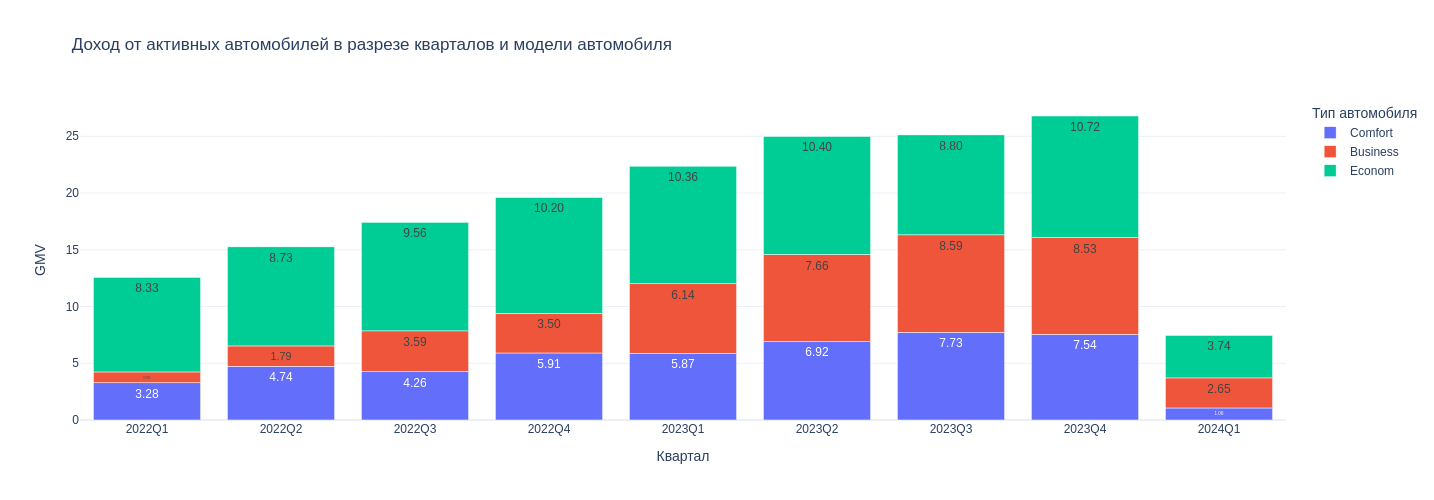

In [6]:
# аггрегация
quarter_revenue_type = df.group_by('quarter','car_type').agg(pl.col('GMV_mln').sum().alias('GMV'))

# Прибыль в разрезе кварталов и модели автомобиля
px.bar(quarter_revenue_type,
       x='quarter',y='GMV',color='car_type',
       category_orders={"quarter": ['2022Q1','2022Q2','2022Q3','2022Q4','2023Q1','2023Q2','2023Q3','2023Q4','2024Q1']},
       template='plotly_white',width=800,height=500,
       labels = {'quarter': 'Квартал', 'total_revenue': 'Чистая прибыль (руб)','car_type':'Тип автомобиля'},
       title='Доход от активных автомобилей в разрезе кварталов и модели автомобиля',
             text_auto='.2f')

- Расспределение дохода от всех трех классов примено одинаковый к концу 2023Q4
- **Эконом** в совокупности приности нам каждый месяц самый высоких доход
- Наращивание дохода от **бизнес** сегмента, вырос от (0.9) в начале периода до (8.5) мл. к концу 2023Q4
- Постепенное увеличение **комфорт** класса, вырос от (3.3) в начале периода до (7.5) мл. к концу 2023Q4
- Стабильный прирост главного источника дохода все 2 года; **эконом**, от (8.3) до (10.7) мл.

## **<span style='color:#686dec'> Прибыль </span>**

Далее посмотрим доходы с учетом расходов

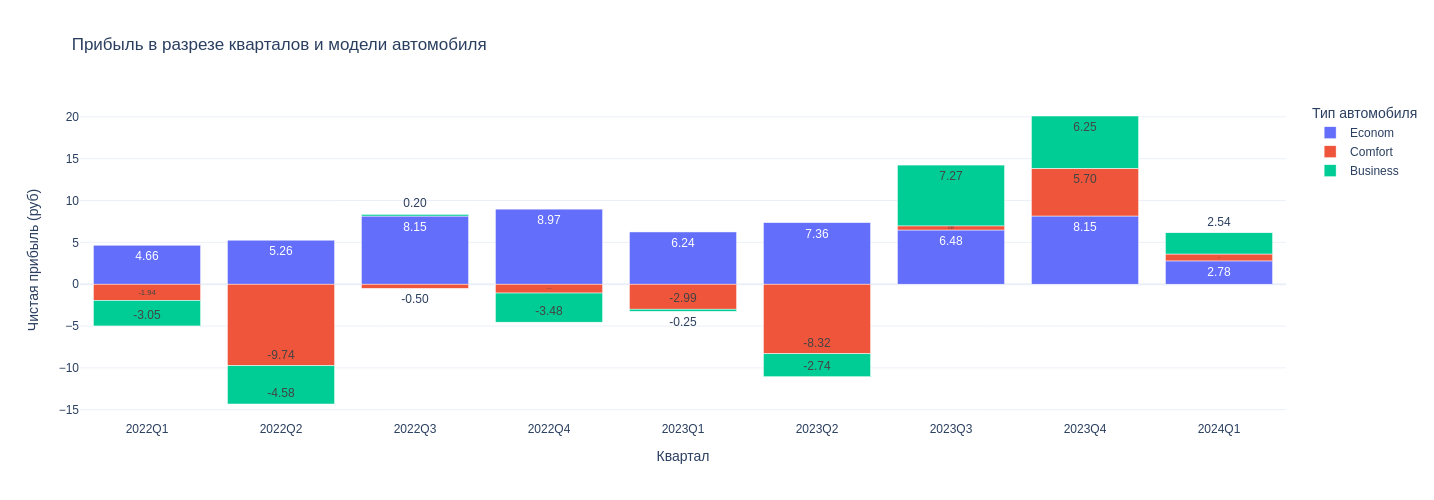

In [7]:
# аггрегация
quarter_revenue_type = df.group_by('quarter','car_type').agg(pl.col('profitability_mln').sum().alias('total_revenue'))

# Прибыль в разрезе кварталов и модели автомобиля
px.bar(quarter_revenue_type,
       x='quarter',y='total_revenue',color='car_type',
       category_orders={"quarter": ['2022Q1','2022Q2','2022Q3','2022Q4','2023Q1','2023Q2','2023Q3','2023Q4','2024Q1']},
       template='plotly_white',width=800,height=500,
       labels = {'quarter': 'Квартал', 'total_revenue': 'Чистая прибыль (руб)','car_type':'Тип автомобиля'},
       title='Прибыль в разрезе кварталов и модели автомобиля',
             text_auto='.2f')

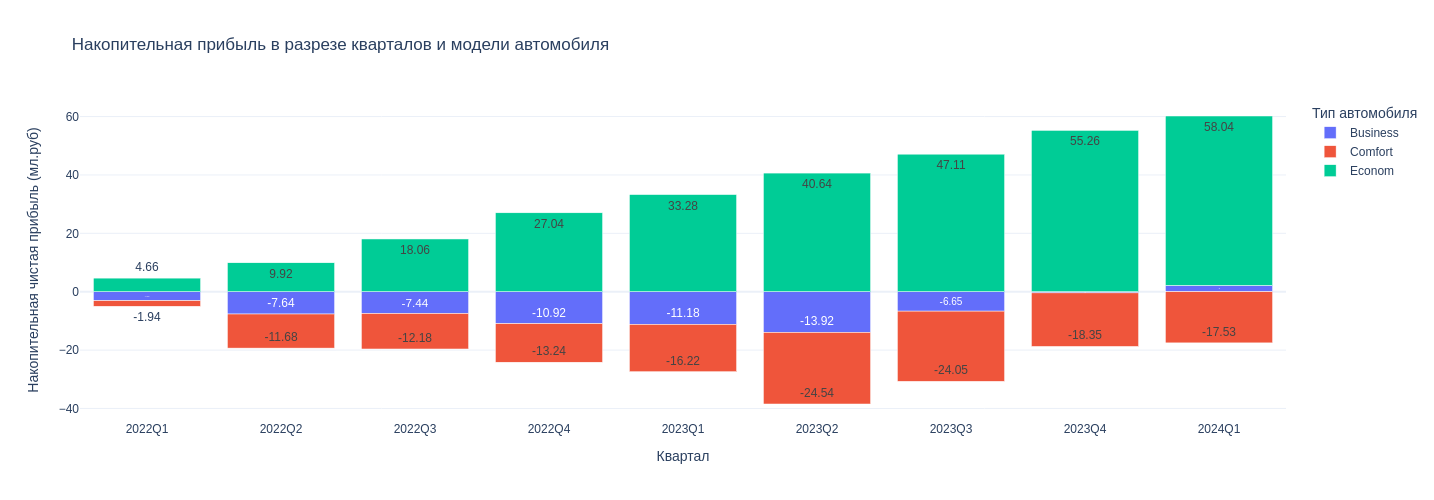

In [8]:
# Накопительная прибыль по кварталам
quarter_revenue_type_accum = (quarter_revenue_type
    .sort(['car_type', 'quarter']) 
    .with_columns(
        pl.col('total_revenue').cum_sum().over('car_type').alias('total_revenue')
    )
    .select(['quarter', 'car_type', 'total_revenue'])
)

# Прибыль в разрезе кварталов и модели автомобиля
px.bar(quarter_revenue_type_accum,
       x='quarter',y='total_revenue',color='car_type',
       category_orders={"quarter": ['2022Q1','2022Q2','2022Q3','2022Q4','2023Q1','2023Q2','2023Q3','2023Q4','2024Q1']},
       template='plotly_white',width=800,height=500,
       labels = {'quarter': 'Квартал', 'total_revenue': 'Накопительная чистая прибыль (мл.руб)','car_type':'Тип автомобиля'},
       title='Накопительная прибыль в разрезе кварталов и модели автомобиля',
             text_auto='.2f')

В разрезе **тип автомобиля**

- **Эконом** показывает стабильный чистый доход все два года (2022,2023), с самого начало был рентабельным и приносил чистый доход
- **Комфорт** в начале 2022 года (Q1,Q2) понес очень существенные убытки и не сумел выйти в плюс в 2022 году, более того, понес еще больше убытков в 2023 году, особенно в Q3. В итоге в 2024Q1, эти убытки составили 17.5м руб.
- **Бизнес** как и с **комфорт** был убыточным (в накопительным смысле) почти все два года но не таких же маштабов, периодически компенсируя расходы и в итоге начал выходить в плюс с 2023Q3. 2023Q3 и 2023Q4 были очень прибыльным для этого класса, показывая положительный тренд для нащего автобизнеса

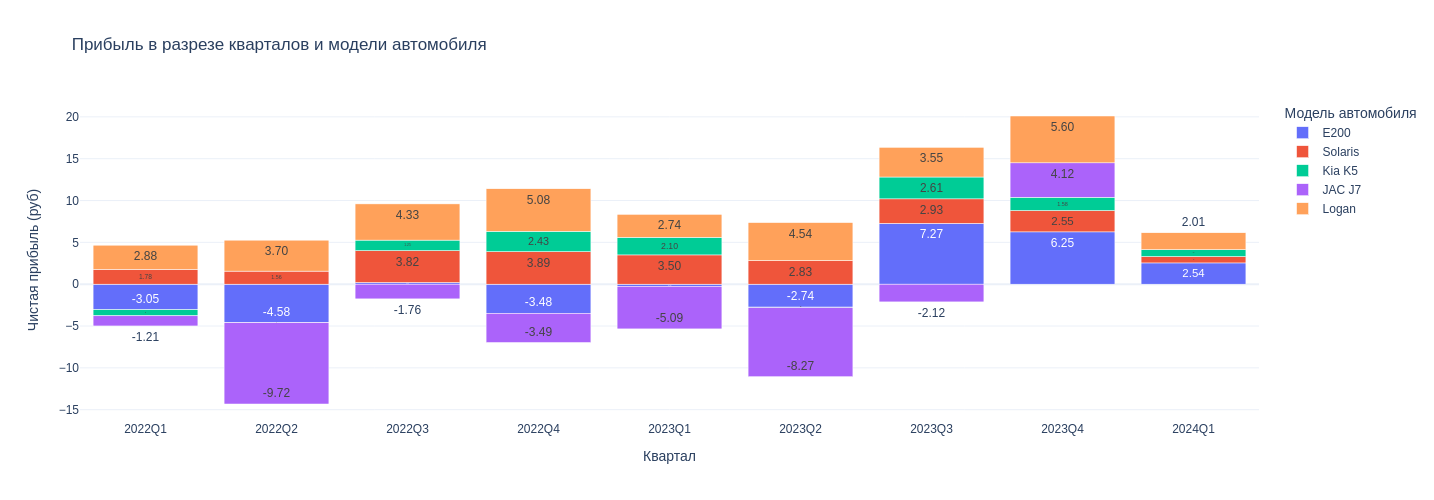

In [9]:
# аггрегация
quarter_revenue_model = df.group_by('quarter','car_model').agg(pl.col('profitability_mln').sum().alias('total_revenue'))

# Прибыль в разрезе кварталов и модели автомобиля
px.bar(quarter_revenue_model,
       x='quarter',y='total_revenue',color='car_model',
       category_orders={"quarter": ['2022Q1','2022Q2','2022Q3','2022Q4','2023Q1','2023Q2','2023Q3','2023Q4','2024Q1']},
       template='plotly_white',width=800,height=500,
       labels = {'quarter': 'Квартал', 'total_revenue': 'Чистая прибыль (руб)','car_model':'Модель автомобиля'},
       title='Прибыль в разрезе кварталов и модели автомобиля',
             text_auto='.2f')

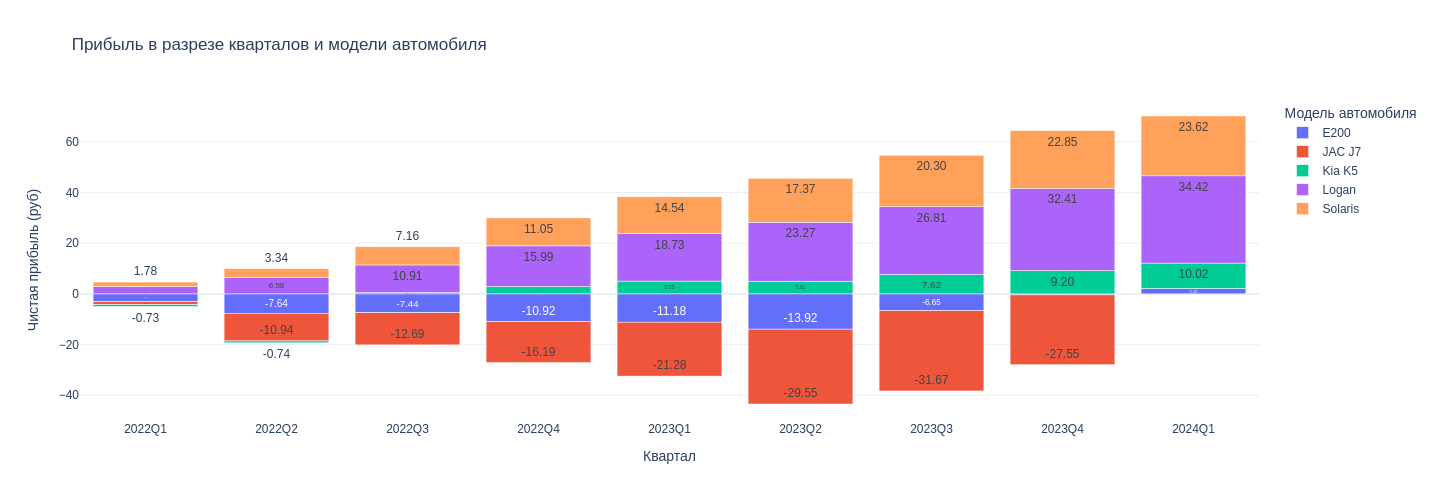

In [10]:
# Накопительная прибыль по кварталам
quarter_revenue_model_accum = (quarter_revenue_model
    .sort(['car_model', 'quarter']) 
    .with_columns(
        pl.col('total_revenue').cum_sum().over('car_model').alias('total_revenue')
    )
    .select(['quarter', 'car_model', 'total_revenue'])
)

# Прибыль в разрезе кварталов и модели автомобиля
px.bar(quarter_revenue_model_accum,
       x='quarter',y='total_revenue',color='car_model',
       category_orders={"quarter": ['2022Q1','2022Q2','2022Q3','2022Q4','2023Q1','2023Q2','2023Q3','2023Q4','2024Q1']},
       template='plotly_white',width=800,height=500,
       labels = {'quarter': 'Квартал', 'total_revenue': 'Чистая прибыль (руб)','car_model':'Модель автомобиля'},
       title='Прибыль в разрезе кварталов и модели автомобиля',
             text_auto='.2f')

Продолжим с данными в разрезе **модели автомобиля**

Для **эконом** и **комфорт** у нас по две модели, соответсвенно изучим данные более детально
- Для эконом обе модели (**solaris**,**logan**) показывали положительную чистую прибыль
- В целом **logan** за два года стала самым прибыльным в точки зрения чистой прибыли нашем парке, даже в 1.45 раза больше **solaris** (того же класса)

Для **комфорт** данные существенно отличаются в разрезе модели
-  Мы видим что именно **JAC J7** показывал существенные убытки
- **Kia K5** в итоге показала не большой но постепенный рост чистой прибыли, то есть именно эта модель была рентабельна, а **JAC J7** наоборот нет
- Не смотря на все убытки в 2022 и 2023, **JAC J7** начала выходить в плюс чистой прибыли уже в 2023Q4
- Для 2024Q1 данные для дохода **JAC J7** отсутствовали

## **<span style='color:#686dec'> Нагрузка автопарка</span>**

Добавим еще одну фичу; **active_load** : доля активных автомобилей, эти данные покажут нам нагрузку автивных автомобилей, относительно всего возможного парка, если автомобили выходили из строя, нагрузка соответсвенно падает

In [11]:
df = df.with_columns(((pl.col('active_cars')/pl.col('car_qnty'))*100).alias('active_load'))

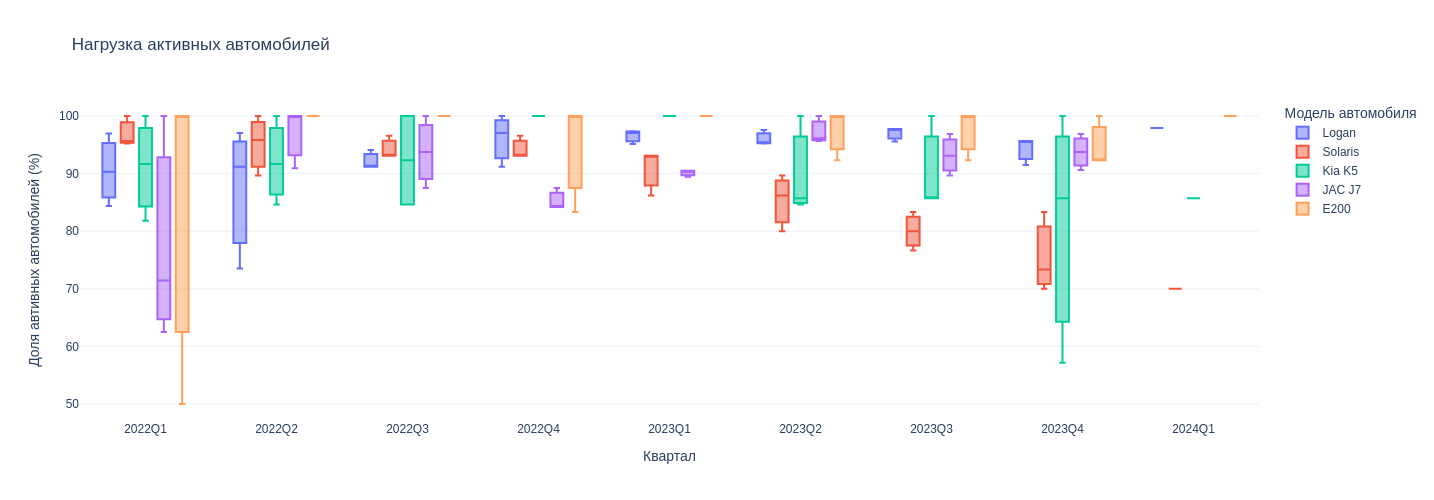

In [12]:
px.box(df,x='quarter',y='active_load',color='car_model',
       template='plotly_white',width=800,height=500,
       labels = dict_map,
       title='Нагрузка активных автомобилей')

- Низкие показатели автивности моделей **JAC J7** и **E200** в начале 2023 года
- Постепенное понижение показателя для **Solaris** (70% к 2023Q4), при этом для **Logan** этот показатель стабилно > 90%

## **<span style='color:#686dec'> Ремонт Автопарка </span>**

Иследуем данные связаны с ремонтов автопарка, добавим долю машин в ремонте для каждой модели

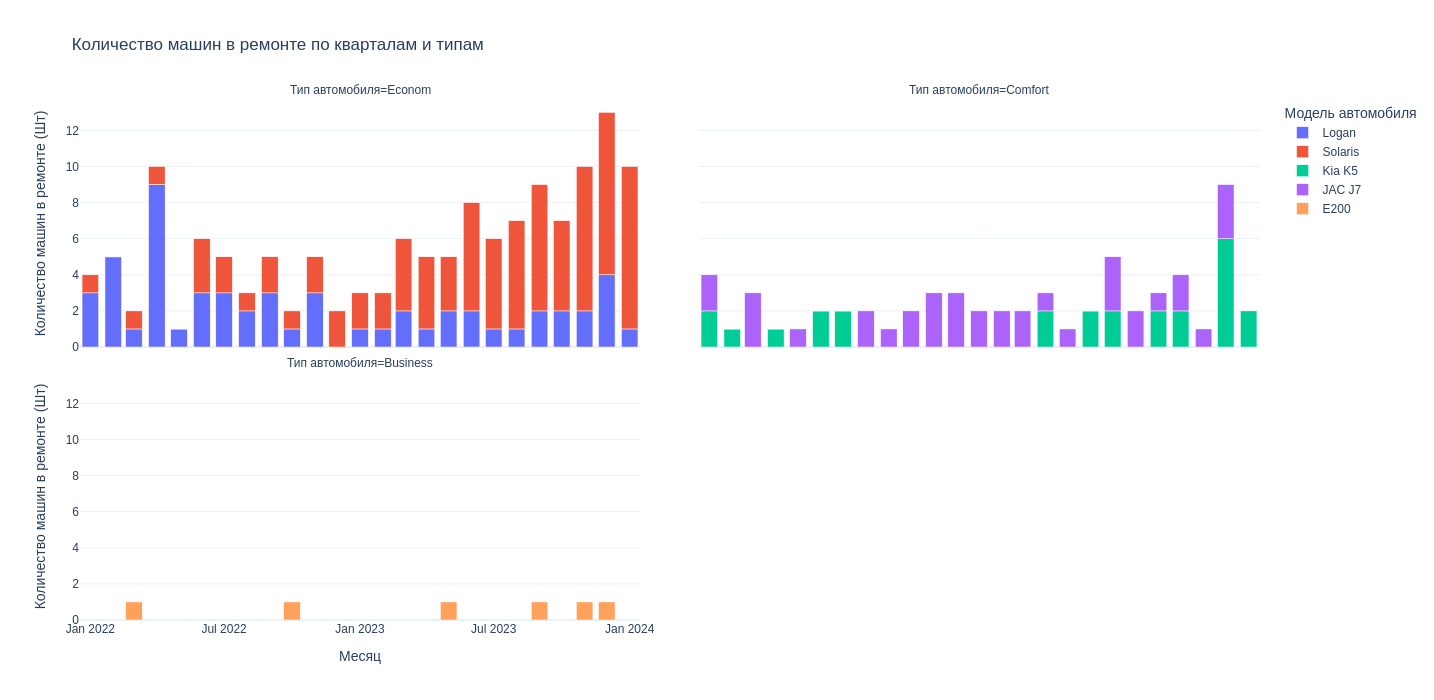

In [13]:
fig = px.bar(df, x='dt', y='bad_cars', color='car_model',
             facet_col='car_type',
             template='plotly_white', width=800, height=700,
             facet_col_wrap=2,
             labels=dict_map,
                          facet_row_spacing=0.05,facet_col_spacing=0.05,
             title='Количество машин в ремонте по кварталам и типам')
fig.show()

- Мы видим что эконом машины достаточно часто выводятся из строя.
- Особенно **Logan** в начале 2022 и уже под конец 2023 года модель **Solaris**, что привело к существенному росту к концу 2023 года
- А целом для **комфорт** количество машин для обоих моделей колеблется в районе (2) машин каждый месяц.
- С исключением декабря 2023 когда (6) **Kia K5** вышло из строя
- **Бизнес** стал чаще выходит из строя к концу 2023 года

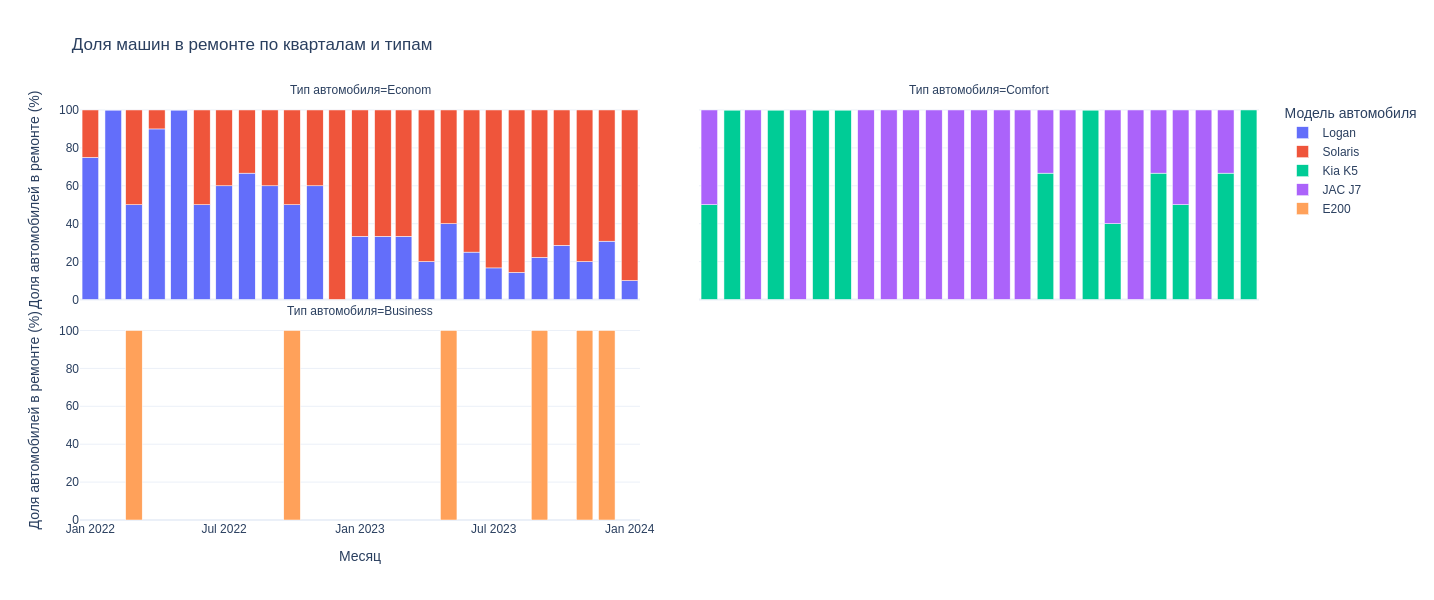

In [14]:
# Normalise bad_cars to sum=1 per (dt, car_type) group
df = df.with_columns(
    (100*pl.col("bad_cars") / pl.col("bad_cars").sum().over(["dt", "car_type"])).alias("bad_cars_norm")
)

fig = px.bar(df, x='dt', y='bad_cars_norm', color='car_model',
             facet_col='car_type',
             template='plotly_white', width=800, height=600,
             facet_col_wrap=2,
             labels=dict_map,
                          facet_row_spacing=0.05,facet_col_spacing=0.05,
             title='Доля машин в ремонте по кварталам и типам')
fig.show()

Между классами

- Можно отметить увеличивующию долю Solaris для **эконом** которые попадают в ремонт (из всех в ремонте)
- Для **комфорт** класса, картина достаточно разнообразная, обе модели примепно равновеными пропорциям попадают в ремонт
- Для **бизнес**, количество ремонов начилось увеличиватся к концу 2023 года

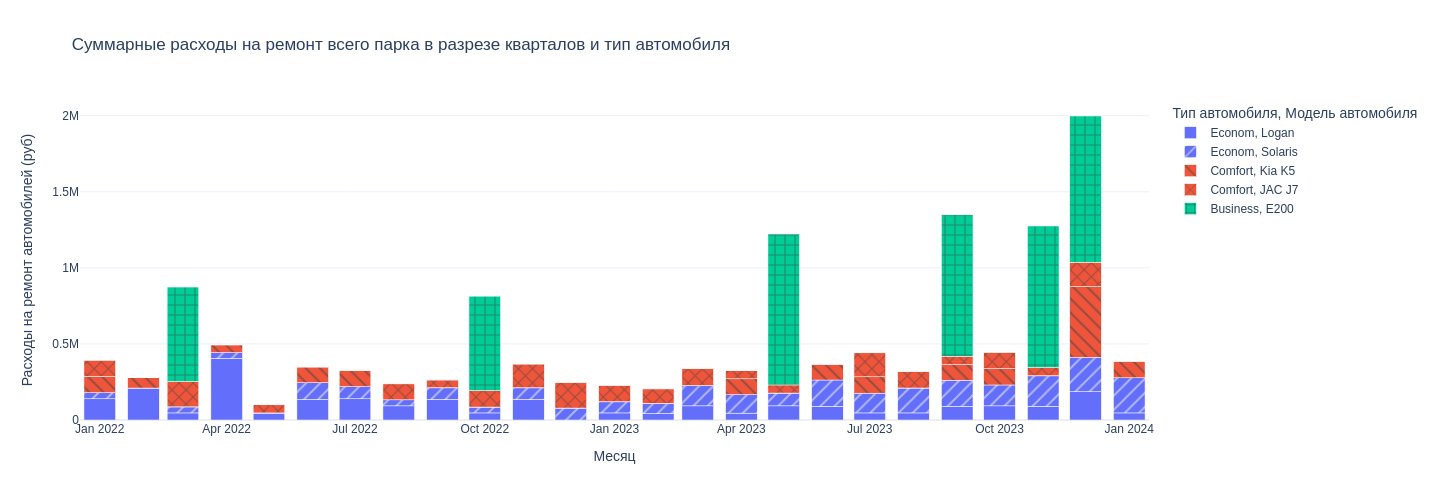

In [15]:
px.bar(df,x='dt',y='money_outcome_repairs',color='car_type',
       pattern_shape='car_model',
       template='plotly_white',width=1000,height=500,
       labels = dict_map,
       title='Суммарные расходы на ремонт всего парка в разрезе кварталов и тип автомобиля')

- Можно в целом отметить увеличение затрат на ремонт автомобилей к концу 2023 года, всех трех типов автомобилей в парке (**Solaris**,**Kia K5** и **E200**)

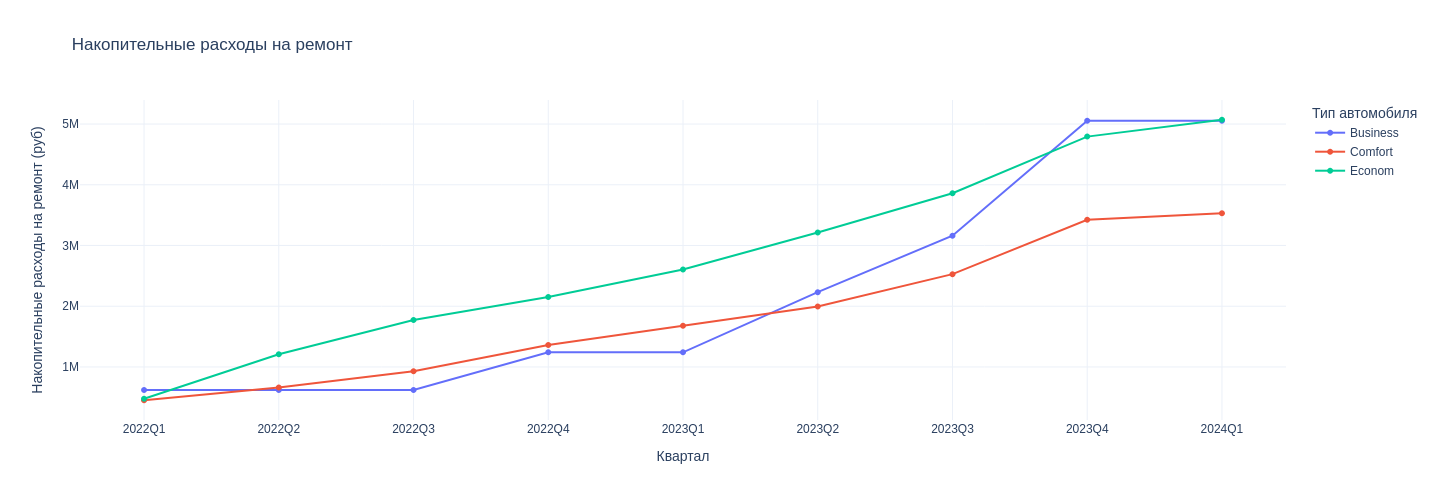

In [16]:
# аггрегация
quarter_repairs = df.group_by('quarter','car_type').agg(pl.col('money_outcome_repairs').sum().alias('total_repairs'))
quarter_repairs

# Накопительная прибыль по кварталам
quarter_repairs_accum = (quarter_repairs
    .sort(['car_type', 'quarter']) 
    .with_columns(
        pl.col('total_repairs').cum_sum().over('car_type').alias('total_repairs')
    )
    .select(['quarter', 'car_type', 'total_repairs'])
)

# Прибыль в разрезе кварталов и модели автомобиля
px.line(quarter_repairs_accum,
       x='quarter',y='total_repairs',color='car_type',
       category_orders={"quarter": ['2022Q1','2022Q2','2022Q3','2022Q4','2023Q1','2023Q2','2023Q3','2023Q4','2024Q1']},
       template='plotly_white',
       width=800,height=500,
        markers=True,
       labels = {'quarter': 'Квартал', 'total_revenue': 'Чистая прибыль (руб)','car_model':'Модель автомобиля','total_repairs':'Накопительные расходы на ремонт (руб)','car_type':'Тип автомобиля'},
       title='Накопительные расходы на ремонт')

- Расходы на ремонт **эконом** класса стабильно являлись самым высоким расходом на ремонт
- Периодические ремонты на **бизнес** увеличили в 2023 году расходы на ремонт от 1.24м до 5.05м
- **Комфорт** показывает самый низкие расходы на ремонт

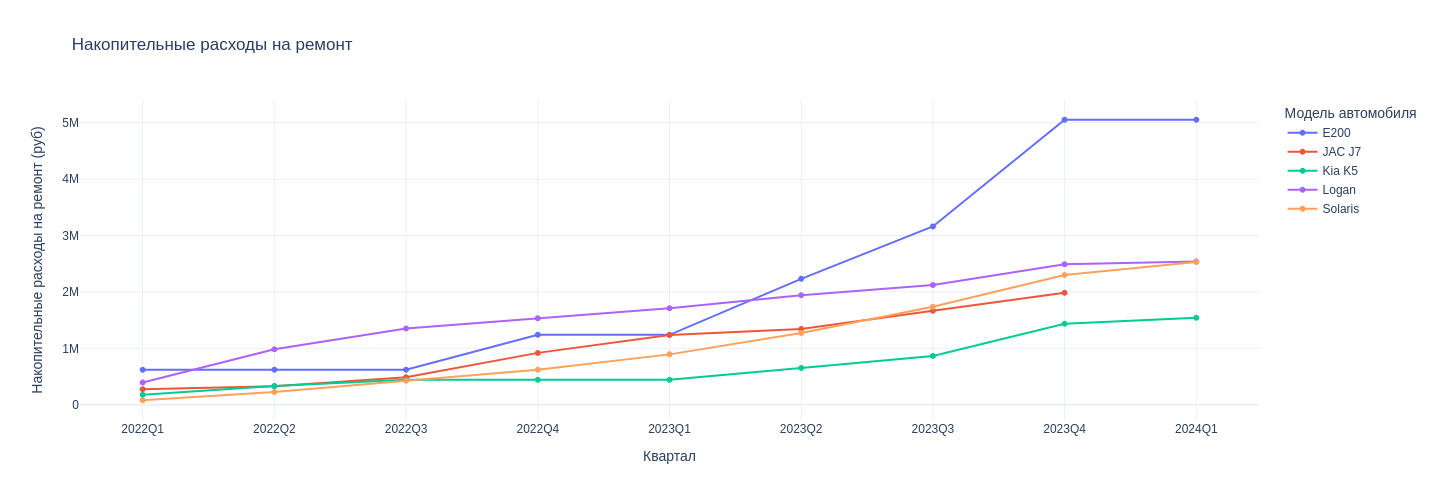

In [17]:
# аггрегация
quarter_repairs = df.group_by('quarter','car_model').agg(pl.col('money_outcome_repairs').sum().alias('total_repairs'))
quarter_repairs

# Накопительная прибыль по кварталам
quarter_repairs_accum = (quarter_repairs
    .sort(['car_model', 'quarter']) 
    .with_columns(
        pl.col('total_repairs').cum_sum().over('car_model').alias('total_repairs')
    )
    .select(['quarter', 'car_model', 'total_repairs'])
)

# Прибыль в разрезе кварталов и модели автомобиля
px.line(quarter_repairs_accum,
       x='quarter',y='total_repairs',color='car_model',
       category_orders={"quarter": ['2022Q1','2022Q2','2022Q3','2022Q4','2023Q1','2023Q2','2023Q3','2023Q4','2024Q1']},
       template='plotly_white',width=800,height=500,markers=True,
       labels = {'quarter': 'Квартал', 'total_revenue': 'Чистая прибыль (руб)','car_model':'Модель автомобиля','total_repairs':'Накопительные расходы на ремонт (руб)','car_type':'Тип автомобиля'},
       title='Накопительные расходы на ремонт')

- Расходы на ремонт **Solaris** были существенно ниже чем **Logan**, к 2024Q1 стали более или менее одинаковыми 2.5м
- Расходы на ремон **Kia K5** суммарно ниже чем у **JAC J7**

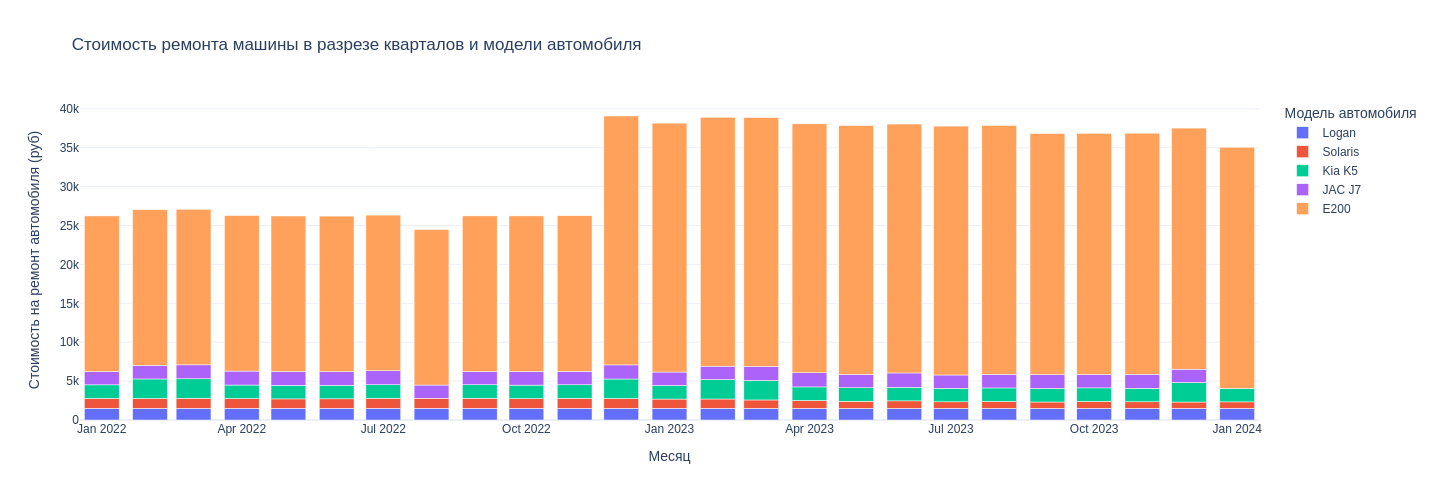

In [18]:
px.bar(df,x='dt',y='repair price',color='car_model',
       template='plotly_white',width=800,height=500,
       labels = dict_map,
       title='Стоимость ремонта машины в разрезе кварталов и модели автомобиля')

Посмотрев на распределение **количество автомобилей в ремонте** 

- Можно так же отметить уменьшаюшие расходов на ремонт для модели **Solaris** (1300 -> 800), а для **Logan** стабильная цена (1500)
- Ремонт **Kia K5** немного больше обходится чем модель аналогичного типа, **JAC J7**, но можно отметить что они выходили из строя меньше, особенно 2022Q4 и 2023Q1
- Расходы для **бизнес** модель **E200** увеличились в 2023 на примерно 50%, что существенно повлияло на расходы в 2023Q3 так как машины два месяца подряж вышли из строя

## **<span style='color:#686dec'> Распределение расходов</span>**

Все расходы в нашем **дереве метрик** можно разделить на 3 части 
- **money_outcome_repairs** : Расходы на ремонты (испледовали выше)
- **new_cars_outcome** : Расходы на покупки новых автомобилей
- **money_outcome_other** : Прочие расходы (страховка, недобросовестные водители и тд)

Нам нужно понять где случается прирост в разных разрезах, для такого анализа надо данные немного преобразовать

In [19]:
melted = df.unpivot(index=['quarter'])
melted = melted.filter(pl.col('variable').is_in(['money_outcome_repairs','money_outcome_other','new_cars_outcome']))
melted = melted.with_columns(pl.col('value').cast(pl.Int64).alias('value'))
melted = melted.group_by('quarter','variable').agg(pl.col('value').sum().alias('value')) # sum all rows
melted = melted.with_columns((pl.col('value')/1000000).alias('value'))

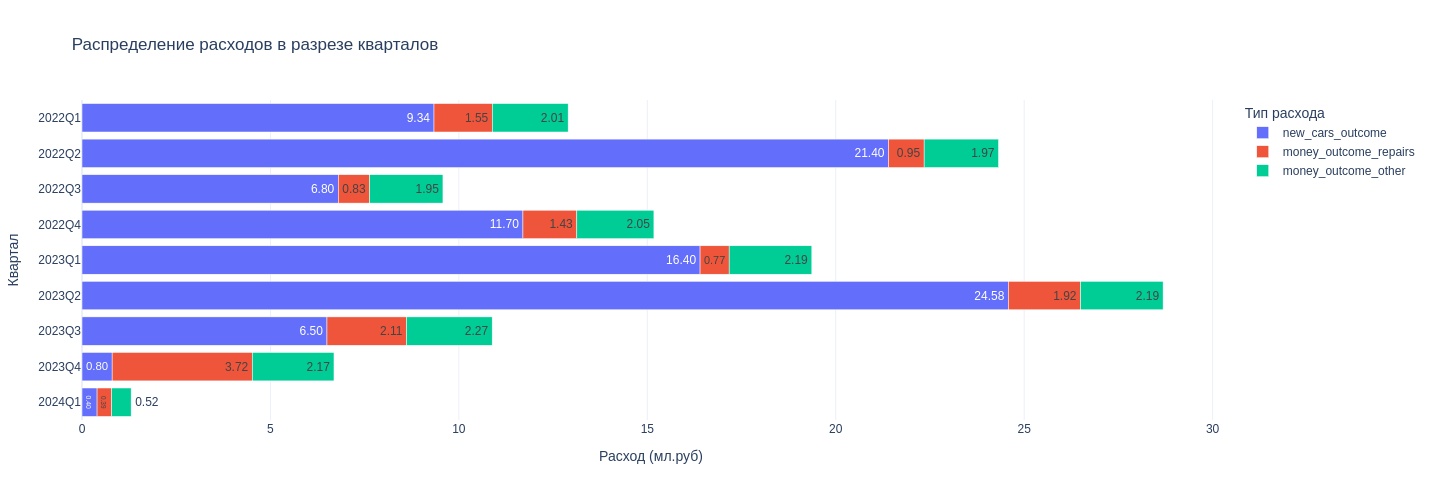

In [20]:
px.bar(melted,y='quarter',x='value',color='variable',
      labels = {'quarter': 'Квартал', 'value': 'Расход (мл.руб)','variable':'Тип расхода'},
      title='Распределение расходов в разрезе кварталов',
      category_orders={"quarter": ['2022Q1','2022Q2','2022Q3','2022Q4','2023Q1','2023Q2','2023Q3','2023Q4','2024Q1']},
      template='plotly_white',width=800,height=500,text_auto='.2f')

- Расходы на инвестиции новых автомобилей составлял самые большие траты, особенно можно отметить 2022Q2 и 2023Q2, в которых этот показатель привышал 20м руб.
- Ракже отметить можно увеличение расходов на ремоны в 2023Q3, это показатель достиг 3.7м руб.

In [21]:
melted = df.unpivot(index=['quarter','car_type'])
melted = melted.filter(pl.col('variable').is_in(['money_outcome_repairs','money_outcome_other','new_cars_outcome']))
melted = melted.with_columns(pl.col('value').cast(pl.Int64).alias('value'))
melted = melted.group_by('quarter','car_type','variable').agg(pl.col('value').sum().alias('value')) # sum all rows
melted = melted.with_columns((pl.col('value')/1000000).alias('value'))

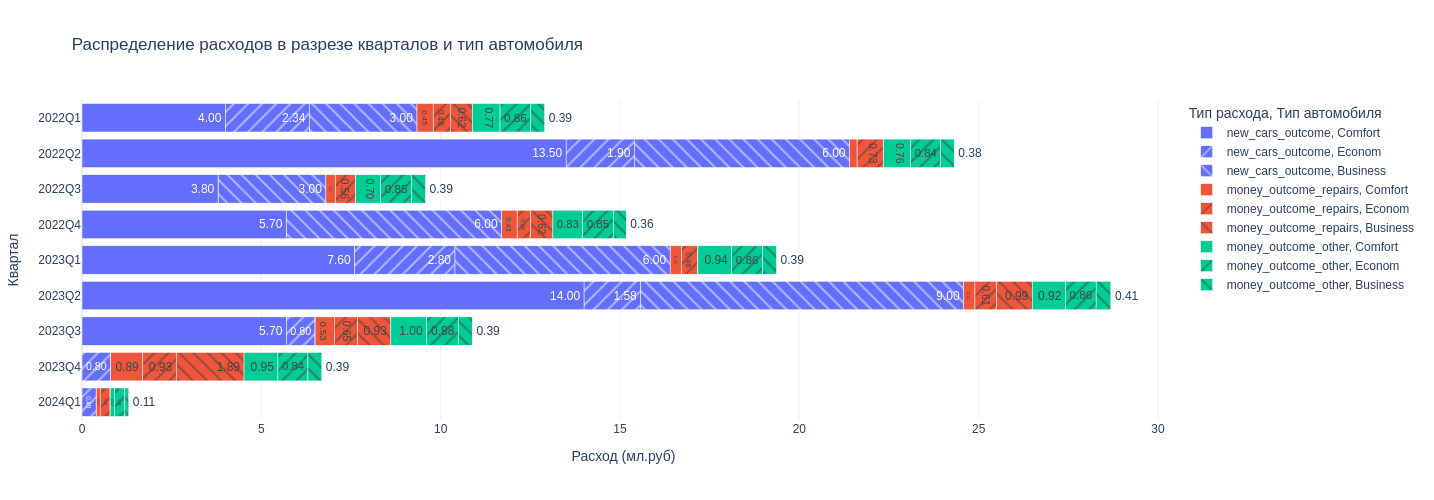

In [22]:
px.bar(melted,y='quarter',x='value',color='variable',pattern_shape='car_type',
      labels = {'quarter': 'Квартал', 'value': 'Расход (мл.руб)','variable':'Тип расхода','car_type':'Тип автомобиля'},
      title='Распределение расходов в разрезе кварталов и тип автомобиля',
      category_orders={"quarter": ['2022Q1','2022Q2','2022Q3','2022Q4','2023Q1','2023Q2','2023Q3','2023Q4','2024Q1']},
      template='plotly_white',width=1000,height=500,text_auto='.2f')

In [23]:
melted = df.unpivot(index=['quarter','car_model'])
melted = melted.filter(pl.col('variable').is_in(['money_outcome_repairs','money_outcome_other','new_cars_outcome']))
melted = melted.with_columns(pl.col('value').cast(pl.Int64).alias('value'))
melted = melted.group_by('quarter','car_model','variable').agg(pl.col('value').sum().alias('value')) # sum all rows
melted = melted.with_columns((pl.col('value')/1000000).alias('value'))

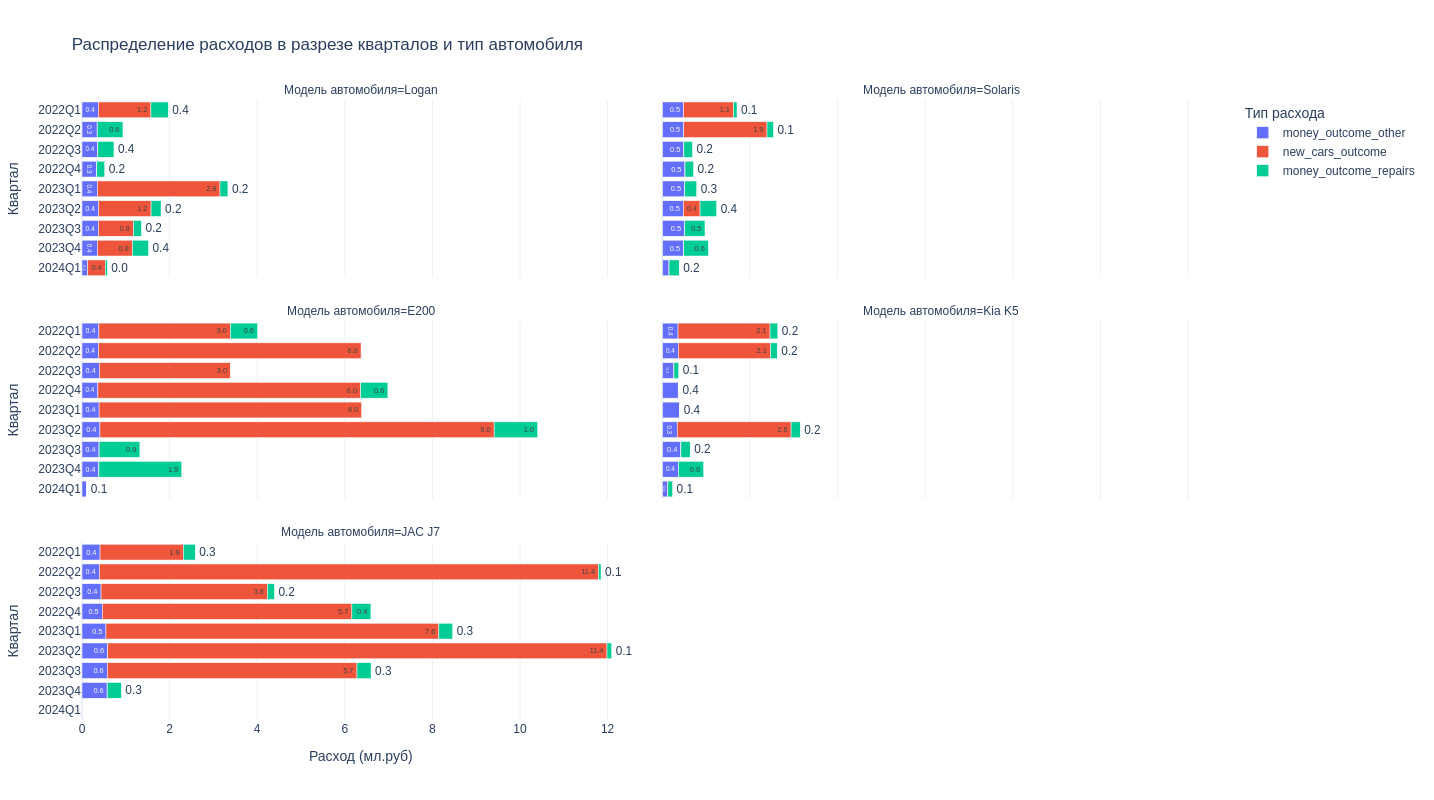

In [24]:
px.bar(melted,y='quarter',x='value',color='variable',facet_col='car_model',facet_col_wrap=2,
      labels = {'quarter': 'Квартал', 'value': 'Расход (мл.руб)','variable':'Тип расхода','car_type':'Тип автомобиля','car_model':'Модель автомобиля'},
      title='Распределение расходов в разрезе кварталов и тип автомобиля',
      category_orders={"quarter": ['2022Q1','2022Q2','2022Q3','2022Q4','2023Q1','2023Q2','2023Q3','2023Q4','2024Q1']},
      template='plotly_white',width=1000,height=800,text_auto='.1f')

- Покупка **бизнес** класс автомобилей происходило на протяжении 1 года (2022Q1 - 2023Q2) после чего новых инвестиции не было
- Большинство расходов на автомобилей составлял **комфорт**, а точнее **JAC J7**

## **<span style='color:#686dec'> Рентабельность автобизнеса</span>**

Рентабельность автобизнеса оцениваем как оношение доходов на расходы. Можно отметить что покупки автомобилей занимают существенную чать всех расходов, соответсвеноо нужно понять как это влияет на рентабельности автобизнеса, инвестировать нужно только в определенные модели которые себя хорошо показали на исторических данных. Так же и учтем наличие автомобилей в ремонтах, так как это второй критичный фактор который влияет на рентабельность автобизнеса

Добавим несколько новых фичей в нашу таблицу:

- **rentability** : Доход / Расход
- **nis_flag** : Наличие хотя бы одной машины в ремонте
- **pur_flag** : Наличие тотя бы одной новой машины

In [25]:
df = df.with_columns((pl.col('revenue')/(pl.col('money_outcome_repairs') + pl.col('money_outcome_other') + pl.col('new_cars_outcome'))).alias('rentability'))
df = df.with_columns((pl.col('bad_cars') > 0).alias('nis_flag'))
df = df.with_columns((pl.col('new_cars') > 0).alias('pur_flag'))

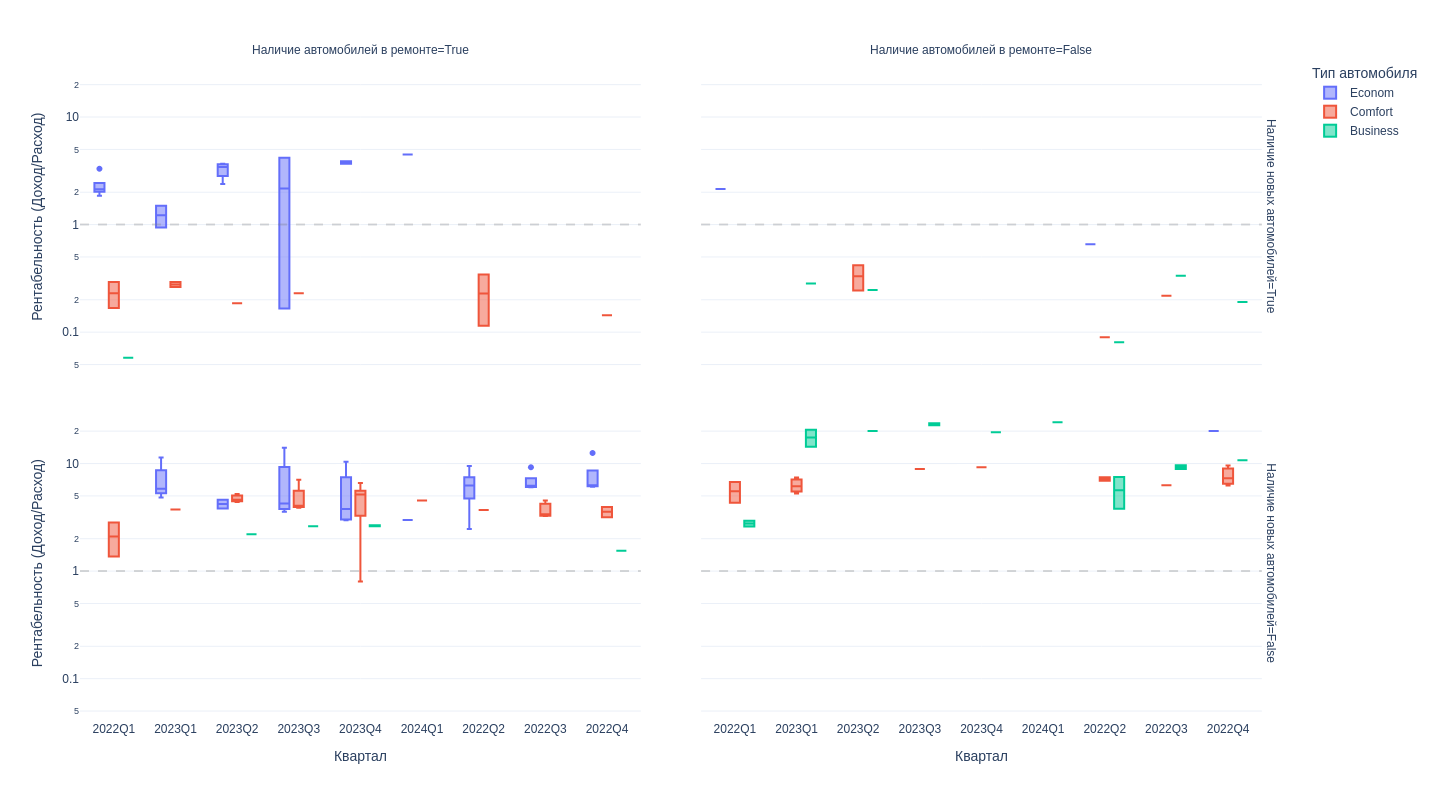

In [26]:
fig = px.box(df,x='quarter',y='rentability',color='car_type',facet_row='pur_flag',facet_col='nis_flag',
      template='plotly_white',width=1000,height=800,log_y=True,
      labels = {'quarter': 'Квартал', 'rentability': 'Рентабельность (Доход/Расход)',
                'car_type':'Тип автомобиля','car_model':'Модель автомобиля',
                'nis_flag':'Наличие автомобилей в ремонте',
                'pur_flag':'Наличие новых автомобилей'},
             facet_row_spacing=0.05,facet_col_spacing=0.05
            )

fig.add_hline(y=1, line_dash="dash", line_color="grey",opacity=0.3)

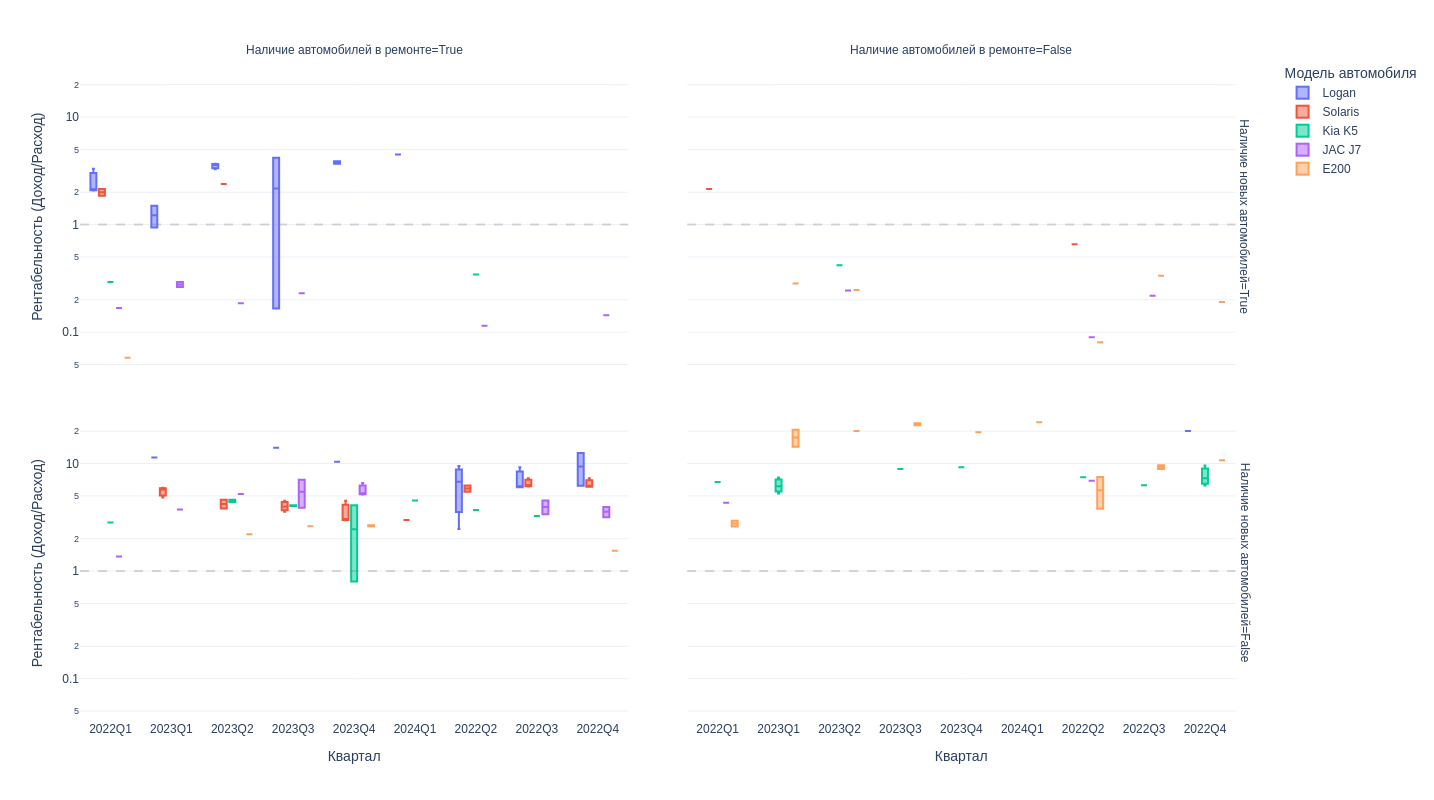

In [27]:
fig = px.box(df,x='quarter',y='rentability',color='car_model',facet_row='pur_flag',facet_col='nis_flag',
      template='plotly_white',width=1000,height=800,log_y=True,
      labels = {'quarter': 'Квартал', 'rentability': 'Рентабельность (Доход/Расход)',
                'car_type':'Тип автомобиля','car_model':'Модель автомобиля',
                'nis_flag':'Наличие автомобилей в ремонте',
                'pur_flag':'Наличие новых автомобилей'},
             facet_row_spacing=0.05,facet_col_spacing=0.05
            )

fig.add_hline(y=1, line_dash="dash", line_color="grey",opacity=0.3)

## **<span style='color:#686dec'> Тренды рентабельности</span>**

Посмотрим еще на общие тренды рентабельности при новых инвестиции автомобилей разных классов и моделей 

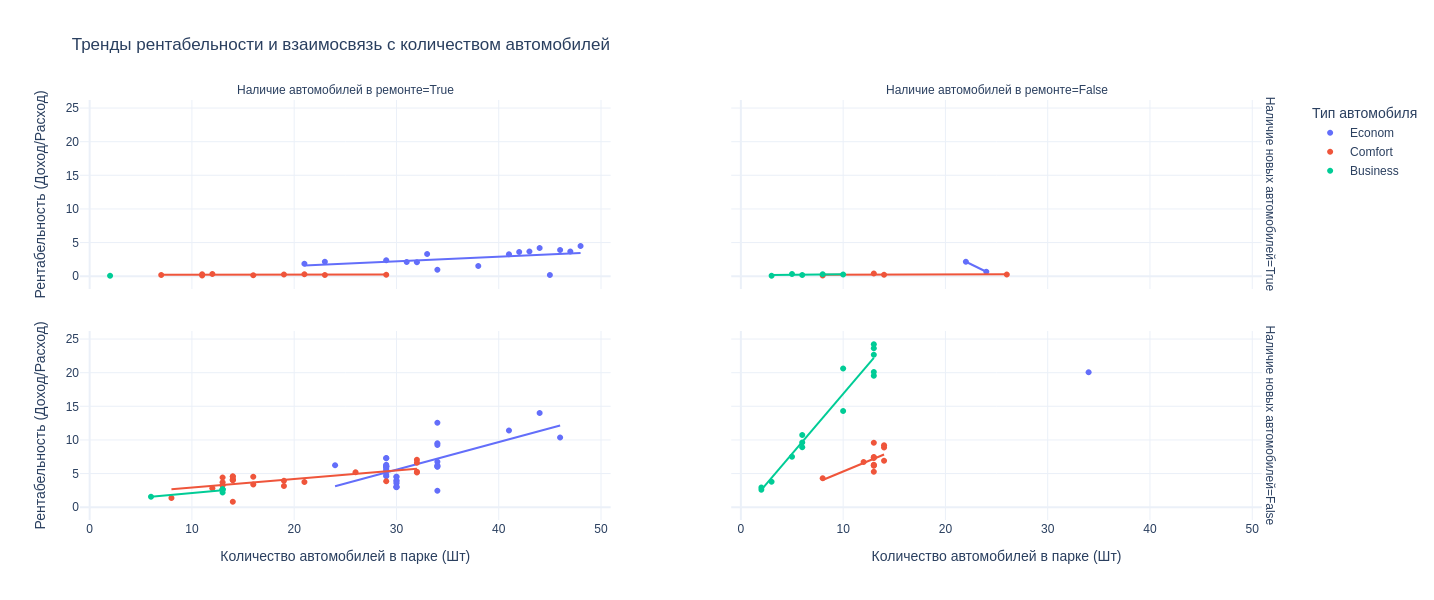

In [28]:
px.scatter(df,x='car_qnty',y='rentability',facet_row='pur_flag',facet_col='nis_flag',
                 template='plotly_white',width=1000,height=600,log_y=False,
                color='car_type',
      labels = {'quarter': 'Квартал', 'rentability': 'Рентабельность (Доход/Расход)',
                'car_type':'Тип автомобиля','car_model':'Модель автомобиля',
                'nis_flag':'Наличие автомобилей в ремонте',
                'pur_flag':'Наличие новых автомобилей','car_qnty':'Количество автомобилей в парке (Шт)'},
             facet_row_spacing=0.1,facet_col_spacing=0.1,
           title='Тренды рентабельности и взаимосвязь с количеством автомобилей',
           trendline="ols")

Инвестируя в покупку новых автомобилей, окупаемость у всех моделей и тип автомобилей разная, посмотрим на данные в разрезе **типа автомобиля**

- Рентабельность у автомобилей **эконом** существенно выше чем у **комфорта**, рост рентабельности выше во всех 4 сценариях, что дает автобизнесу беспрерывно получать чистую прибыль.
- При **наличии машин в ремонте и при покупке новых автомобилей** **эконом** все равно почти каждый месяц остается рентабельным, и при расширении парка, оно имеет тенденцию расти (0.06)
- При **наличии машин в ремонте но отсутсвии новый автомобилей**, совокупно **эконом** показывает самые высокий рост рентабельности, но разброс данных немного больше чем у **комфорта** и **бизнес** классов, что говорит о блияния других факторов (например поломки) 
- Отсутсвии данных **эконом** когда закупки новых автомобилей не было говорит о том что мы **часто закупаем автомобили этого класса**, рентабельность при отсутсвии поломок показывает рентабельность на уровне автомобилей **бизнес** класса, потребуется больше данных для потверждении
- Покупка автомобилей **комфорт** и **бизнес** класса отбрасывает рентабельность менльше 1 почти во всех кварталах
- **Бизнес** класс очень редко ломаются, но **когда это не случается**, темп роста рентабельности с увеличение количество автомобилей в парке имеет самый высокие показатели (1.78) на машину, у **комфорта** этот показатель (0.63)

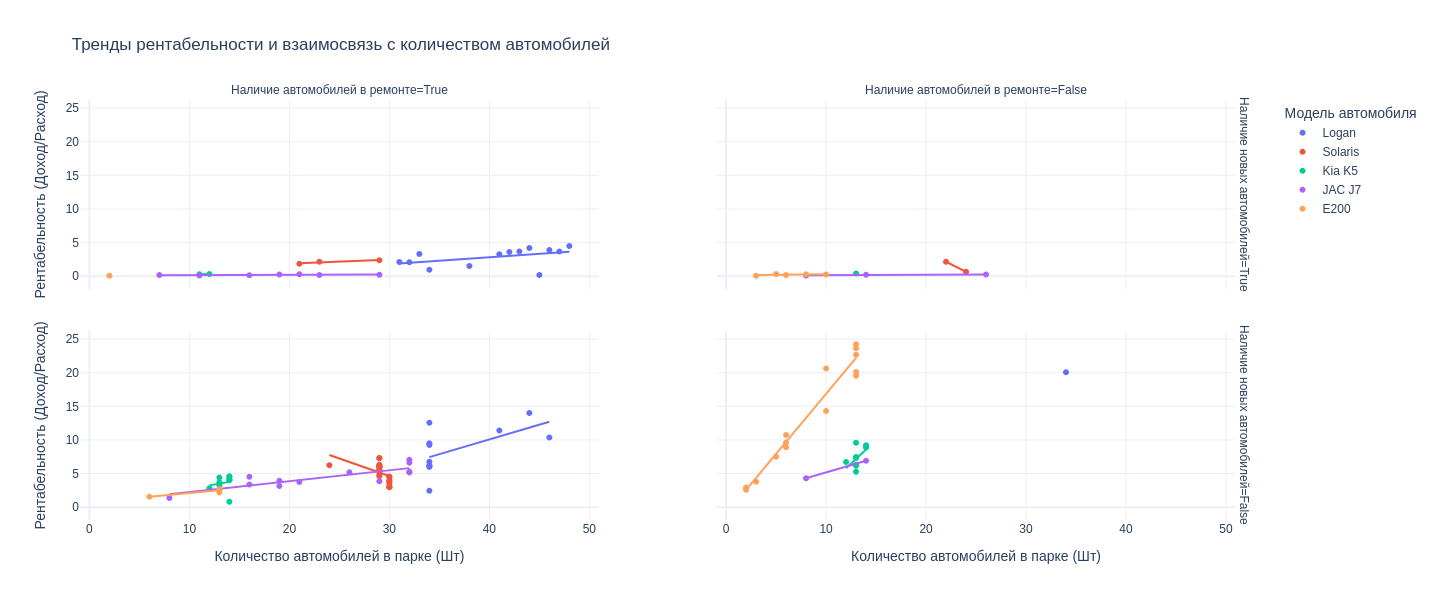

In [29]:
px.scatter(df,x='car_qnty',y='rentability',facet_row='pur_flag',facet_col='nis_flag',
                 template='plotly_white',width=1000,height=600,log_y=False,
                color='car_model',
      labels = {'quarter': 'Квартал', 'rentability': 'Рентабельность (Доход/Расход)',
                'car_type':'Тип автомобиля','car_model':'Модель автомобиля',
                'nis_flag':'Наличие автомобилей в ремонте',
                'pur_flag':'Наличие новых автомобилей','car_qnty':'Количество автомобилей в парке (Шт)'},
             facet_row_spacing=0.1,facet_col_spacing=0.1,
           title='Тренды рентабельности и взаимосвязь с количеством автомобилей',
           trendline="ols")

Инвестируя в покупку новых автомобилей, окупаемость у всех моделей и тип автомобилей разная

- При наличии **автомобилей в ремонте** и при **покупуе новых автомобилей**, тенденции роста рентабельности **эконом** класса (**Solaris** и **Logan**) особо нет (0.06)
- При наличии автомобилей в ремонте и при покупуе новых автомобилей, тенденции роста рентабельности **эконом** класса так же примерно одинаковые, но у **Kia K5** показатели рентибельности немного выше
- При наличии автомобилей в ремонте но без новых автомобилей, рентабельность у **Kia K5** так же выше чем у **JAC J7**, значении и сами тенденции (0.26) и (0.16)
- При наличии автомобилей в ремонте но без новых автомобилей, рентабельность у **эконом** **Logan** в целом выше чем у аналога **solaris**, тенденции так же (0.43) и (-0.5)
- Так же можно отметить и случай когда нет новых автомобилей и автомобилей в ремонте, у **Kia K5** выше показатели, тенденция (1.39)

In [30]:
ldf = df.select(pl.col('dt','car_model','car_type','car_qnty','money_outcome_repairs','money_outcome_other','new_cars_outcome'))
subsets = dict(tuple(ldf.group_by('car_model','car_type')))
subsets.keys()

dict_keys([('Solaris', 'Econom'), ('Logan', 'Econom'), ('Kia K5', 'Comfort'), ('JAC J7', 'Comfort'), ('E200', 'Business')])

# <b>5 <span style='color:#686dec'>|</span> Итог</b> 

## **<span style='color:#686dec'> Гипотезы о причинах роста автопарка</span>**

Укажем 4 гипотезы, 3 на которые мы нашли ответы в данных, а последний требует дальнейшей проверки

    
    Гипотеза 1: Рост бизнеса без новых покупок

    Рентабельность растет в периоды без расширений автопарка, так как 
    фиксированные затраты распределяются на существующий флот эффективнее. 
    Без капитальных вложений в новые машины маржа увеличивается за счет 
    оптимизации использования текущих активов

    
    Гипотеза 2: Торможение рентабельности новыми покупками
      
    Покупки новых автомобилей существенно замедляют рост рентабельности 
    (как показывают регрессионные тренды), так как стоимость автомобилей 
    очень существенная отностителтно доходов, но в целом увеличивают доходы со 
    временем — это подтверждает рост чистой прибыли по моделям.

    
    Гипотеза 3: Драйвер роста бизнес к концу 2023
      
    Стабильный доход от эконом класса все два года дал нам возможност инвестировать 
    в комфорт и бизнес классы, что со временем дало больше прибыли, так как автомобили 
    выходят из строя меньше чем автомобили из эконом класса, что приводит к высоким 
    показателям рентабельности 

    
    Гипотеза 4: Не качественные ремонты эконом класса (Для проверки)

    Поиск оптимизации ремонта и снижение стоимости расходов на ремонт автомобилей класса 
    эконом негативно отразилась на рентабельности автомобилей Solaris.

## **<span style='color:#686dec'> Стратегию развития</span>**

Ключевые выводы и стратегические цели, которые можно сделать на
основании анализа данных на предыдущем шаге:

    Стратегически можно сфокусироваться на развитии бизнеса в
    тарифах Комфорт и Бизнес, т.к. они более перспективны: в них
    автомобили требуют меньше ремонта, аренда стоит дороже и по
    итогу быстро выводят экономику в плюс.

    Если по стратегическим причинам хочется развивать Эконом, то
    стоит делать акцент на модели Solaris, так как есть точка роста 
    Но очень важно разобраться с тем, что там происходит с машинами в ремонте.

    В “Комфорте” желательно достичь преобладание JAC J7 и более
    грамотно выстроить прайсинг, чтобы снизить накладные
    расходы.

    Во всех тарифах в месяцы с праздниками (декабрь, февраль,
    март) присутствует повышенный спрос, нужно стараться
    выводить больше машин и по максимум сокращать ремонт в эти
    месяцы.